# Notebook Dedicated to Study the Directional Pattern of the Solar Candidates

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import glob

# Load Data

## Load the ntuple Info

In [26]:
main_dir = '/home/joankl/data/solars/real_data/bisMSB/first_candidates/analysis*/resume_files/'
obs_list_ntuple = ['eventID', 'energy_corrected', 'posr_av']
obs_dict_ntuple = {var_i: np.array([]) for var_i in obs_list_ntuple}

for obs_i in obs_list_ntuple:
    flist = glob.glob(main_dir + obs_i + '.npy') # List of directories where the obs is

    for f_i in flist:
        array_i = np.load(f_i)
        obs_dict_ntuple[obs_i] = np.append(obs_dict_ntuple[obs_i], array_i)

# Apply Cut
en_cut = 5.0

condition = (obs_dict_ntuple['energy_corrected'] >= en_cut)

evtid_ntuple = obs_dict_ntuple['eventID'][condition]
energy = obs_dict_ntuple['energy_corrected'][condition]

## Load the numpy from RATDS Info and Perform Time Residual Cut

In [12]:
#main_dir = '/home/joankl/data/solars/real_data/bisMSB/first_candidates/np_files/'
main_dir = 'E:/Data/solars/solarnu_Realdata/bisMSB/first_candidates/analysis*/ratds/np_files/'
obs_list_ratds = ['cos_alpha', 'evtid', 'energy_corr', 'posr', 'hit_residual']
obs_dict_ratds = {var_i: np.array([]) for var_i in obs_list_ratds}

for obs_i in obs_list_ratds:
    flist = glob.glob(main_dir + obs_i + '*.npy')

    for f_i in flist:
        array_i = np.load(f_i)
        obs_dict_ratds[obs_i] = np.append(obs_dict_ratds[obs_i], array_i)

cos_alpha = obs_dict_ratds['cos_alpha']
time_res = obs_dict_ratds['hit_residual']
energy = obs_dict_ratds['energy_corr']
posr = obs_dict_ratds['posr']
evtid_ratds = obs_dict_ratds['evtid']

# ------ Time Residual Cut ------
t_res_min = -1
t_res_max = 5

tres_condition = (time_res >= t_res_min) & (time_res <= t_res_max)

cos_alpha = cos_alpha[tres_condition]
energy = energy[tres_condition]
posr = posr[tres_condition]

In [13]:
min(energy)

4.984167575836182

# Extract the Unique eventID (non per hit)

# Directionality Plot

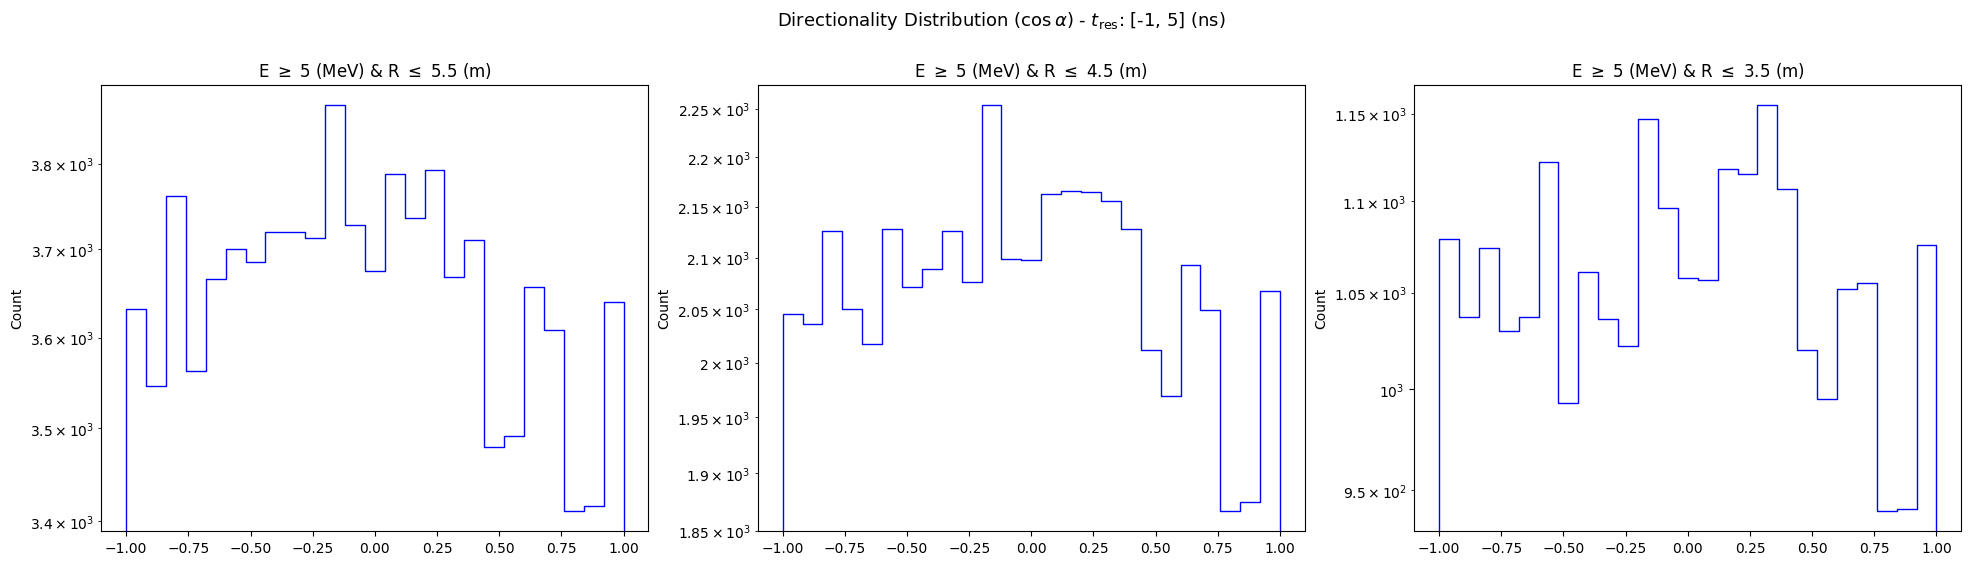

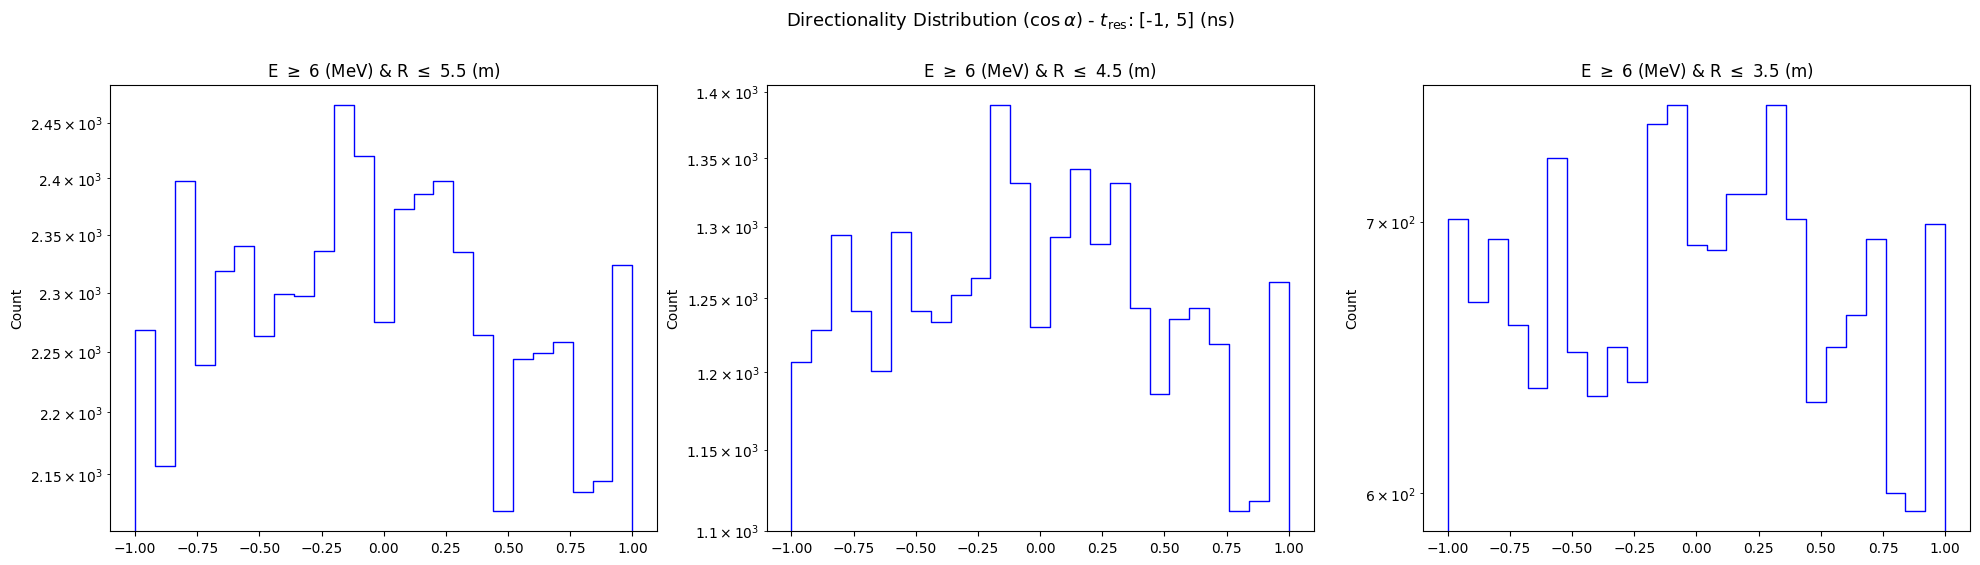

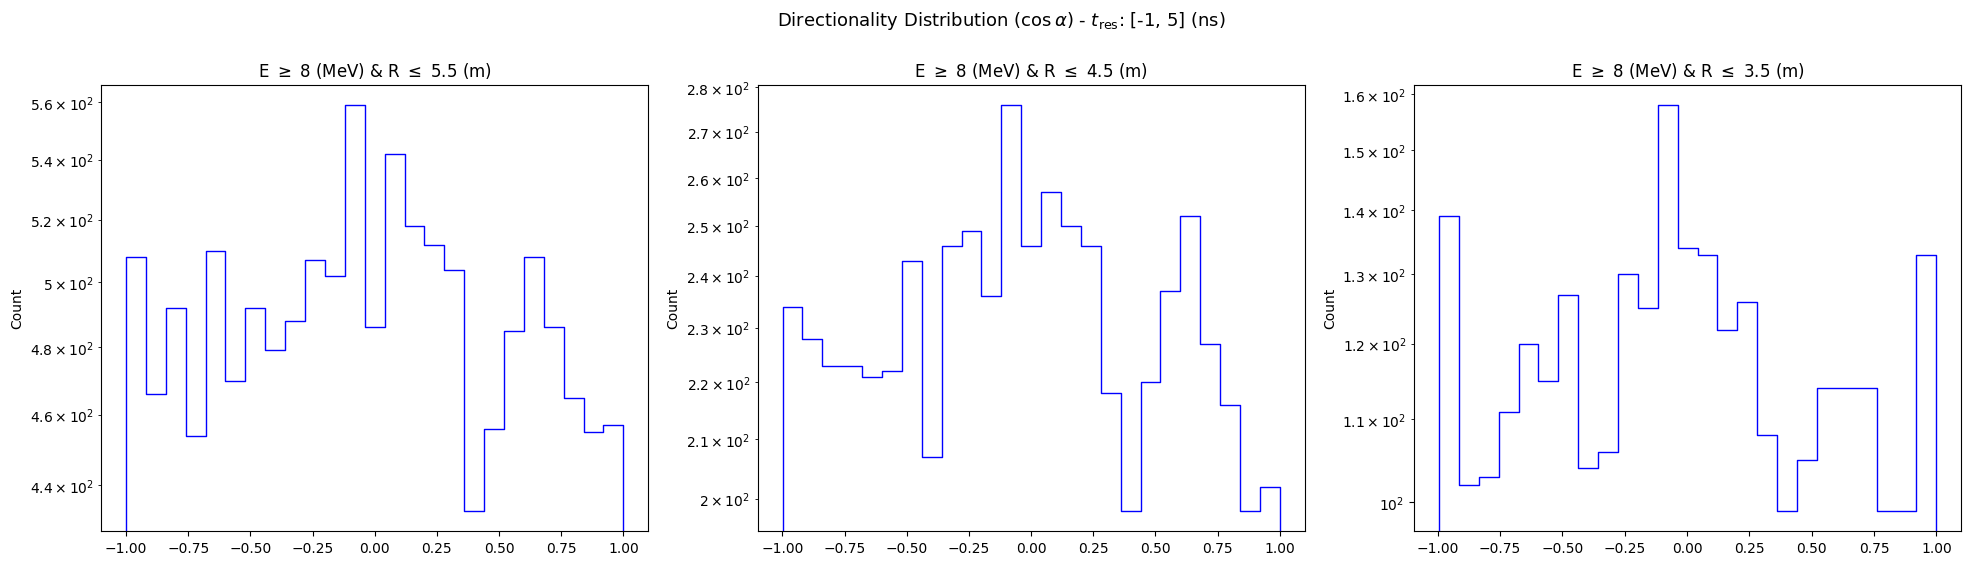

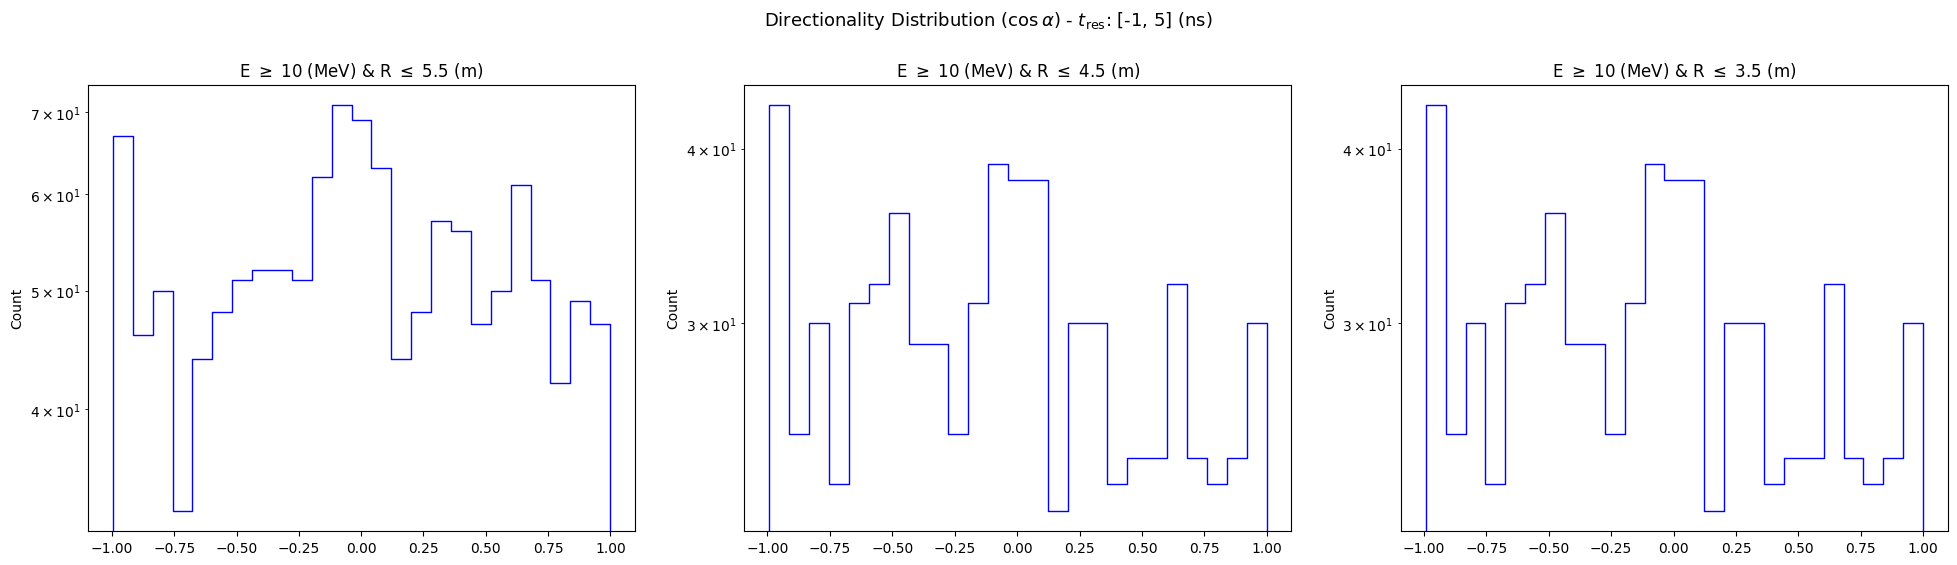

In [15]:
bins = 25
# ------ Define Cuts ------
E_cut_list = [5, 6, 8, 10]
R_cut_list = [5500, 4500, 3500]

for Ecut_i in E_cut_list:
    en_cut_condition = (energy >= Ecut_i)
    
    fig, axes = plt.subplots(1, len(R_cut_list), figsize=(24, 5.8))
    
    for i_dx, Rcut_i in enumerate(R_cut_list):
        posr_cut_condition = (posr <= Rcut_i)
        cut_condition = en_cut_condition & posr_cut_condition
        
        cos_alpha_cut = cos_alpha[cut_condition]
        
        ax = axes[i_dx]
    
        sn.histplot(cos_alpha_cut, ax = ax, bins = bins, alpha = 0, element = 'step', color = 'blue')

        ax.set_title(fr'E $\geq$ {Ecut_i} (MeV) & R $\leq$ {Rcut_i*10**(-3)} (m)')
        ax.set_yscale('log')

    plt.suptitle(fr'Directionality Distribution ($\cos\alpha$) - $t_\mathrm{{res}}$: [{t_res_min:.0f}, {t_res_max:.0f}] (ns)', fontsize = 13, y = 1.01)

    plt.show()